# Intermediate Performance Charts
Insertion throughput over time for each dataset, showing time-per-insertion,
OD count, cache evictions, and optional static-algorithm baseline.

In [1]:
from chart_utils import *
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
def plot_intermediate_performance(full_files, plot_idx, second_half_files=None, ax1=None, dataset_name=None):
    """
    Create a performance chart for intermediate data.

    Parameters:
    - full_files: List of Path objects for the full (0-100%) run
    - second_half_files: Optional list of Path objects for the second half run
    - ax1: Matplotlib axes to plot on (creates new figure if None)
    - dataset_name: Optional dataset name for title and static comparison

    Returns:
    - (ax1, ax2): Tuple of primary and secondary axes
    """
    if not full_files:
        return None, None

    if dataset_name is None:
        base_name, _ = split_intermediate_variant(normalize_intermediate_name(full_files[0]))
        dataset_name = base_name

    if ax1 is None:
        fig, ax1 = plt.subplots(figsize=(10, 6))

    ax2 = ax1.twinx()

    full_df = get_first_run(load_intermediate_runs(full_files))
    if full_df.empty:
        return ax1, ax2

    # Highlight cache evictions
    eviction_rows = full_df[full_df['cacheEvitionsDiff'] > 0]
    if not eviction_rows.empty:
        max_evictions = eviction_rows['cacheEvitionsDiff'].max()
        for _, row in eviction_rows.iterrows():
            intensity = row['cacheEvitionsDiff'] / max_evictions
            ax1.axvline(
                x=row['lastOperationId'], color='red',
                alpha=0.3 * intensity, linewidth=1.5, zorder=0
            )

    # Static algorithm baseline
    static_data, has_error = parse_static_results(dataset_name)
    if not has_error and len(static_data) > 0:
        avg_time_s = sum(d['time'] for d in static_data) / len(static_data)
        max_op_id = full_df['lastOperationId'].max()
        if max_op_id > 0:
            time_per_tuple = avg_time_s * 1000 / max_op_id
            ax1.axhline(
                y=time_per_tuple, color='gray', linestyle='--',
                linewidth=1.5, label='Static algorithm time per insertion'
            )

    # Time per operation (full run)
    sns.lineplot(
        data=full_df, x='lastOperationId', y='timePerOperation',
        ax=ax1, color='tab:blue', linewidth=1.5,
        label='Time per insertion (0-100%)', errorbar='sd', legend=False
    )

    # OD count (full run)
    sns.lineplot(
        data=full_df, x='lastOperationId', y='totalODs',
        ax=ax2, color='tab:green', linewidth=1.5,
        label='ODs', errorbar='sd', legend=False
    )

    # Second half overlay
    if second_half_files:
        second_half_df = get_first_run(load_intermediate_runs(second_half_files))
        if not second_half_df.empty:
            offset = full_df['lastOperationId'].max() / 2
            second_half_df = second_half_df.copy()
            second_half_df['lastOperationId'] = second_half_df['lastOperationId'] + offset
            sns.lineplot(
                data=second_half_df, x='lastOperationId', y='timePerOperation',
                ax=ax1, color='tab:orange', linewidth=1.5,
                label='Time per insertion (50-100%)', errorbar='sd', legend=False
            )

    ax1.set_xlabel('')
    ax1.set_ylabel('')
    ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.xaxis.set_major_formatter(FuncFormatter(human_format))
    ax1.yaxis.set_major_formatter(FuncFormatter(human_format))

    ax2.set_ylabel('')
    ax2.tick_params(axis='y', labelsize=12)
    ax2.yaxis.set_major_formatter(FuncFormatter(human_format))

    ax1.set_title(format_dataset_name(dataset_name, index=plot_idx), fontsize=12, pad=10, y=0.97)

    return ax1, ax2

## Grid of All Datasets

static search for identifier='abalone' yielded results=[{'memory': 812.0, 'time': 1.918}, {'memory': 897.0, 'time': 1.832}, {'memory': 1036.0, 'time': 1.816}] error_type=None
static search for identifier='actor_final_state' yielded results=[] error_type='oom'
static search for identifier='adult' yielded results=[{'memory': 3974.0, 'time': 138.814}, {'memory': 4287.0, 'time': 117.136}] error_type=None
static search for identifier='bridges' yielded results=[{'memory': 324.0, 'time': 0.694}, {'memory': 310.0, 'time': 0.645}, {'memory': 309.0, 'time': 0.647}] error_type=None
static search for identifier='fd-reduced-30' yielded results=[] error_type='oom'
static search for identifier='flights_20_500k' yielded results=[{'memory': 7203.0, 'time': 386.522}, {'memory': 11177.0, 'time': 429.499}] error_type=None
static search for identifier='hepatitis' yielded results=[{'memory': 3868.0, 'time': 57.655}, {'memory': 2007.0, 'time': 58.841}, {'memory': 840.0, 'time': 57.57}] error_type=None
static

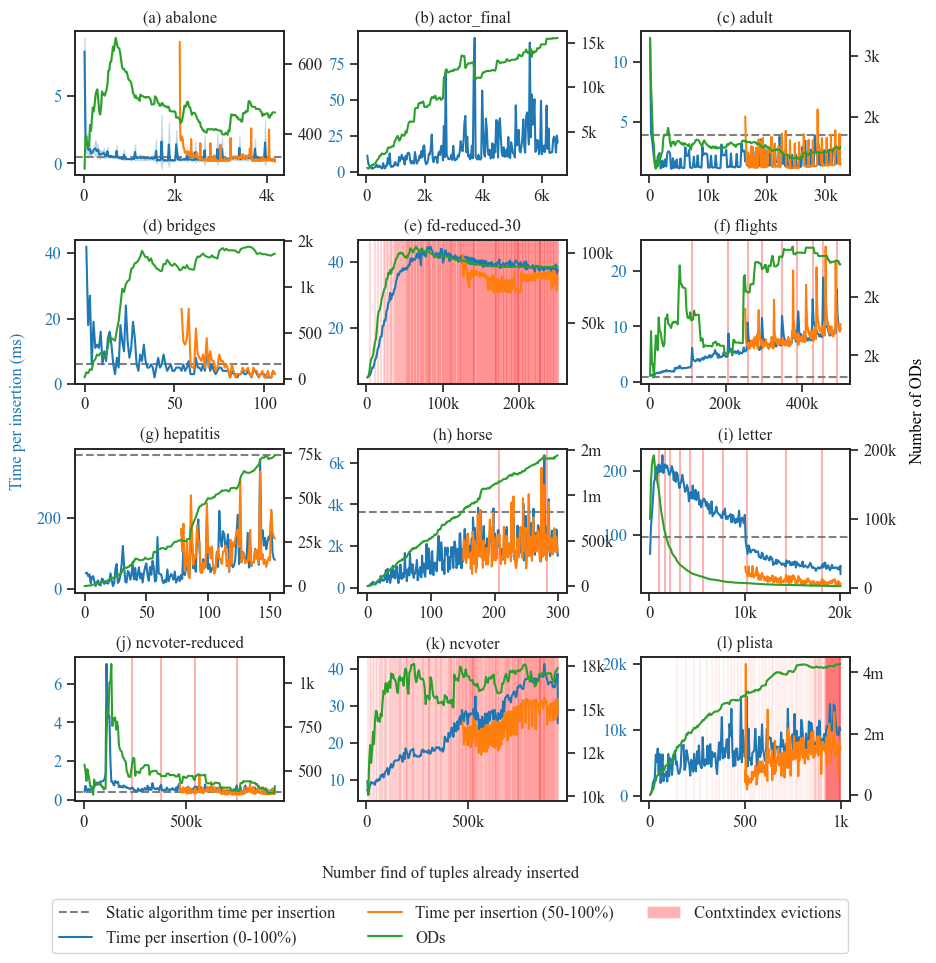

In [9]:
# Collect intermediate files and group by dataset
all_intermediate_files = list(
    (benchmark_data_path / 'dynsbod_results/intermediate/').rglob('*_stdout.intermediate.csv')
)

dataset_files = defaultdict(lambda: defaultdict(list))
for file in all_intermediate_files:
    normalized_name = normalize_intermediate_name(file)
    base_name, variant = split_intermediate_variant(normalized_name)
    if variant == 'first_half':
        continue
    dataset_files[base_name][variant].append(file)

datasets_to_plot = [
    f for f in sorted(dataset_files.keys())
    if 'events' not in f and 'baseline' not in f
]

# Create grid
n_rows, n_cols = 4, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
fig.subplots_adjust(hspace=0.45, wspace=0.35)
axes = axes.flatten()

plot_idx = 0
for dataset_name in datasets_to_plot:
    if plot_idx >= len(axes):
        break
    if 'iris' in dataset_name or 'chess' in dataset_name or 'book' in dataset_name or 'cpu' in dataset_name or 'disease' in dataset_name or 'flights-reduced' in dataset_name:
        continue

    variants = dataset_files[dataset_name]
    if 'full' not in variants:
        continue
    if 'final_state' in dataset_name:
        del variants['second_half']

    plot_intermediate_performance(
        full_files=variants['full'],
        plot_idx=plot_idx,
        second_half_files=variants.get('second_half'),
        ax1=axes[plot_idx],
        dataset_name=dataset_name,
    )
    plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

# Shared legend
if plot_idx > 0:
    legend_elements = [
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5,
               label='Static algorithm time per insertion'),
        Line2D([0], [0], color='tab:blue', linewidth=1.5,
               label='Time per insertion (0-100%)'),
        Line2D([0], [0], color='tab:orange', linewidth=1.5,
               label='Time per insertion (50-100%)'),
        Line2D([0], [0], color='tab:green', linewidth=1.5, label='ODs'),
        Patch(facecolor='red', alpha=0.3, label='Contxtindex evictions'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
              bbox_to_anchor=(0.5, -0.05), fontsize=12)

fig.supxlabel('Number find of tuples already inserted', fontsize=12, y=0.03)
fig.text(0.06, 0.5, 'Time per insertion (ms)', va='center', rotation='vertical',
         fontsize=12, color='tab:blue')
fig.text(0.96, 0.5, 'Number of ODs', va='center', rotation='vertical',
         fontsize=12, color='black')

save_figure("intermediate")
plt.show()

## Laptop Letter Dataset (Single)

static search for identifier='letter_laptop' yielded results=[] error_type=None


Exception: Error reading /Users/paulsieben/Programming/Masterarbeit/algo/benchmark/dynsbod_results/laptop_results/algo0_java0_letter_laptop_second_half_run1_stdout.intermediate.scv: [Errno 2] No such file or directory: '/Users/paulsieben/Programming/Masterarbeit/algo/benchmark/dynsbod_results/laptop_results/algo0_java0_letter_laptop_second_half_run1_stdout.intermediate.scv'

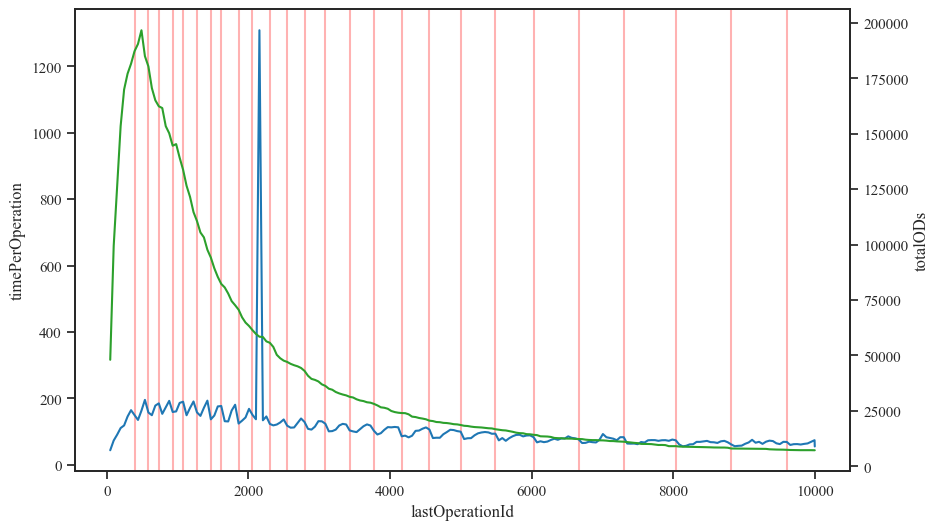

In [4]:
base = Path('/Users/paulsieben/Programming/Masterarbeit/algo/benchmark/dynsbod_results/laptop_results')
plot_intermediate_performance(
    full_files=[base / "algo0_java0_letter_laptop_first_half_run1_stdout.intermediate.csv"],
    plot_idx=0,
    second_half_files=[base / "algo0_java0_letter_laptop_second_half_run1_stdout.intermediate.scv"],
    dataset_name="letter_laptop",
)

static search for identifier='letter_laptop' yielded results=[] error_type=None


(<Axes: title={'center': '(a) letter'}>, <Axes: xlabel='lastOperationId'>)

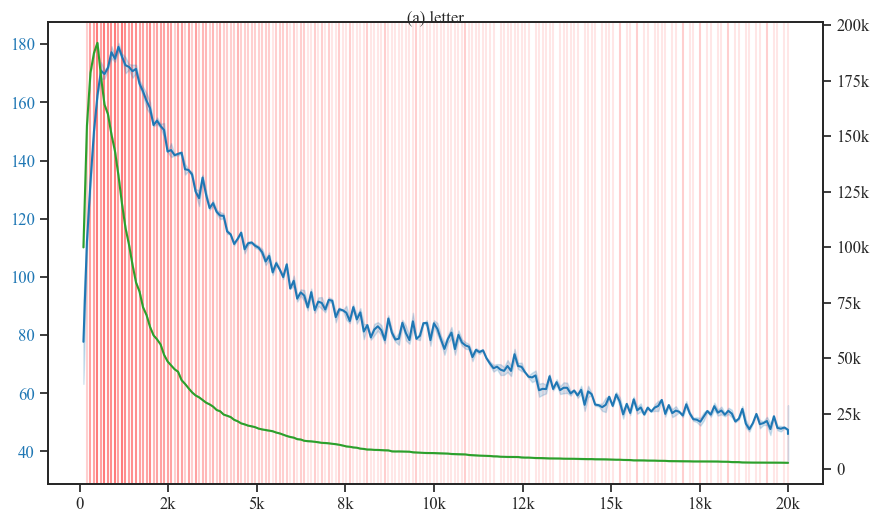

In [ ]:
base = Path('/Users/paulsieben/Programming/Masterarbeit/algo/')
plot_intermediate_performance(
    full_files=[base / "letter_experiments2.intermediate.csv"],
    plot_idx=0,
    # second_half_files=[base / "letter_experiments.intermediate.csv"],
    second_half_files=None,
    dataset_name="letter_laptop",
)